# Notebook 04 — P-Values, t-Statistics & Confidence Intervals

## *A Physicist's Guide to Hypothesis Testing in Regression*

---

**What this notebook covers:**

| # | Topic | Core question |
|---|-------|--------------|
| 1 | Setup & Data Loading | What data and tools do we need? |
| 2 | The Null Hypothesis | What are we actually testing? |
| 3 | The t-Distribution | Why not just use the normal? |
| 4 | t-Statistics for Coefficients | How many standard errors from zero? |
| 5 | The P-Value | How surprised should we be? |
| 6 | Type I & II Errors | What mistakes can we make? |
| 7 | Confidence Intervals | Where does the true $\beta$ live? |
| 8 | Confidence & Prediction Bands | Uncertainty in the line vs new points |
| 9 | The F-Test | Is the *whole* model useful? |
| 10 | ANOVA Table | Decomposing variance |
| 11 | Multiple Testing | The curse of many comparisons |
| 12 | Practical vs Statistical Significance | Big sample ≠ big effect |
| 13 | "Better Than Average" Summary | Model comparison toolkit |
| 14 | Diagnostic Plots | Checking our assumptions |
| 15 | Complete Worked Example | Reading every number in the OLS table |

> 💡 **Physicist's Intuition:** Think of hypothesis testing as *signal detection*.  
> The null hypothesis is your noise model; rejecting it means you've detected signal above the noise floor.


---
## 1. Setup & Data Loading

We need two complementary datasets:

| Dataset | Source | Rows | Task |
|---------|--------|------|------|
| **California Housing** | `sklearn.datasets` | 20 640 | Continuous regression — predict median house value |
| **Titanic** | `seaborn` built-in | 891 | Categorical/survival — ANOVA & group comparisons |

We'll fit an **OLS regression** on California Housing using `statsmodels`, which gives us
the full classical summary table (coefficients, standard errors, t-statistics, p-values,
confidence intervals, $R^2$, $F$-statistic, and more).

By the end of this notebook you will understand **every single number** in that table.


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from sklearn.datasets import fetch_california_housing

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'legend.fontsize': 10,
})
sns.set_style("whitegrid")

np.random.seed(42)
print("✅ All imports loaded successfully.")


✅ All imports loaded successfully.


In [124]:
# --- California Housing ---
housing_bunch = fetch_california_housing(as_frame=True)
housing = housing_bunch.frame
print(f"California Housing: {housing.shape[0]} rows × {housing.shape[1]} cols")
housing.head()


California Housing: 20640 rows × 9 cols


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [125]:
# --- Titanic ---
titanic = sns.load_dataset("titanic").dropna(subset=["age", "fare"])
print(f"Titanic: {titanic.shape[0]} rows × {titanic.shape[1]} cols")
titanic.head()


Titanic: 714 rows × 15 cols


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Fitting our workhorse OLS model

We select four features from California Housing and regress `MedHouseVal` on them.

| Feature | Meaning |
|---------|---------|
| `MedInc` | Median income in block group (tens of thousands of dollars) |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveOccup` | Average number of occupants per household |

We use `sm.add_constant()` to include an intercept $\beta_0$.


In [126]:
feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveOccup"]
X = housing[feature_cols]
y = housing["MedHouseVal"]

X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     5450.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:22:59   Log-Likelihood:                -24802.
No. Observations:               20640   AIC:                         4.961e+04
Df Residuals:                   20635   BIC:                         4.965e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0314      0.022      1.428      0.1

> 🎯 **Key Takeaway:** That table above is the *Rosetta Stone* of regression.  
> By section 15 you'll be able to read every line of it like sheet music.


---
## 2. The Null Hypothesis

### What are we actually testing?

For each coefficient $\hat{\beta}_j$ in the regression, the hypothesis test is:

$$
H_0: \beta_j = 0 \qquad \text{vs} \qquad H_1: \beta_j \neq 0
$$

### Why test against zero?

If the true $\beta_j = 0$, then feature $x_j$ has **no linear relationship** with $y$.
Including it in the model doesn't help — you'd predict just as well by ignoring it entirely.

Consider the simplest regression:

$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

If $\beta_1 = 0$, this collapses to $y = \beta_0 + \varepsilon$, which means our best
prediction is just $\hat{y} = \bar{y}$ — the **mean**. So:

> **"Is $\beta_j$ significantly different from zero?"** is the same as asking  
> **"Does feature $x_j$ do better than just predicting the average?"**

### The courtroom analogy

| Statistics | Courtroom |
|-----------|-----------|
| $H_0$: $\beta_j = 0$ | Defendant is innocent |
| $H_1$: $\beta_j \neq 0$ | Defendant is guilty |
| Data / t-statistic | Evidence presented |
| p-value | Strength of evidence against innocence |
| Reject $H_0$ | Verdict: guilty (beyond reasonable doubt) |
| Fail to reject $H_0$ | Not proven guilty (NOT the same as proven innocent!) |

> 💡 **Physicist's Intuition:** In a particle physics experiment, $H_0$ is "there is no new particle" —
> the background-only hypothesis. You need $5\sigma$ evidence ($p < 2.87 \times 10^{-7}$) to claim
> discovery. In social science, $2\sigma$ ($p < 0.05$) suffices. The *logic* is the same; the threshold differs.

> ⚠️ **Common Misconception:** Failing to reject $H_0$ does NOT mean $H_0$ is true. It means we
> don't have enough evidence to reject it. Absence of evidence ≠ evidence of absence.


---
## 3. The t-Distribution

### When $\sigma$ is known → Z-test

If we know the population standard deviation $\sigma$, the test statistic:

$$
Z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)
$$

follows a standard normal. But **we never know $\sigma$ in practice** — we estimate it from data as $s$.

### Enter William Sealy Gosset

Working at the Guinness brewery in Dublin (1908), Gosset needed to do quality control on small barley
samples. He published under the pseudonym **"Student"** because Guinness didn't want competitors
knowing they used statistics.

When we replace $\sigma$ with the sample estimate $s$:

$$
t = \frac{\bar{x} - \mu}{s / \sqrt{n}} \sim t(\nu), \qquad \nu = n - 1
$$

The resulting distribution has **heavier tails** than the normal — reflecting the extra uncertainty
from estimating $\sigma$.

### Key properties of the $t$-distribution

| Property | Detail |
|----------|--------|
| Shape parameter | $\nu$ = degrees of freedom |
| Mean | 0 (for $\nu > 1$) |
| Variance | $\nu / (\nu - 2)$ for $\nu > 2$ (larger than 1!) |
| Tails | Heavier than normal — extreme values more likely |
| Limit | $t(\nu) \to \mathcal{N}(0, 1)$ as $\nu \to \infty$ |

> 💡 **Physicist's Intuition:** The heavier tails are like adding thermal noise to your measurement.  
> With fewer data points ($\nu$ small), your estimate of the noise floor $s$ is itself noisy,  
> so the *effective* distribution of your test statistic is wider. As $n \to \infty$, $s \to \sigma$  
> and the extra uncertainty vanishes.


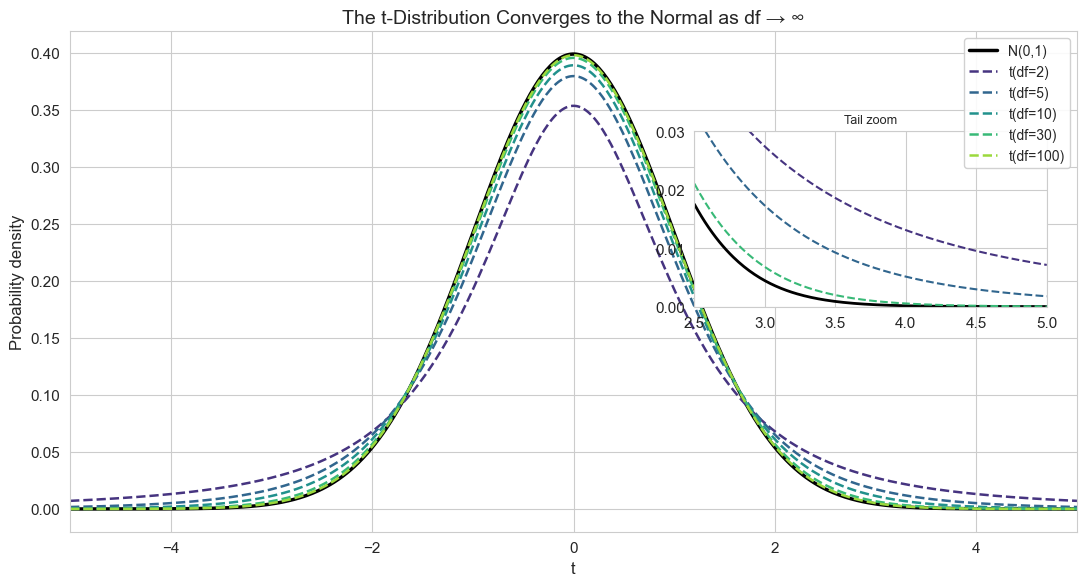

In [127]:
# Plot t-distributions for various degrees of freedom, overlaid with N(0,1)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.linspace(-5, 5, 500)

ax.plot(x, stats.norm.pdf(x), 'k-', lw=2.5, label='N(0,1)')

colors = plt.cm.viridis(np.linspace(0.15, 0.85, 5))
for df, c in zip([2, 5, 10, 30, 100], colors):
    ax.plot(x, stats.t.pdf(x, df), '--', color=c, lw=1.8, label=f't(df={df})')

ax.set_xlabel('t')
ax.set_ylabel('Probability density')
ax.set_title('The t-Distribution Converges to the Normal as df → ∞')
ax.legend(frameon=True, framealpha=0.9)
ax.set_xlim(-5, 5)

# Inset: zoom on the tails
axins = ax.inset_axes([0.62, 0.45, 0.35, 0.35])
x_tail = np.linspace(2.5, 5, 200)
axins.plot(x_tail, stats.norm.pdf(x_tail), 'k-', lw=2)
for df, c in zip([2, 5, 30], [colors[0], colors[1], colors[3]]):
    axins.plot(x_tail, stats.t.pdf(x_tail, df), '--', color=c, lw=1.5)
axins.set_title('Tail zoom', fontsize=9)
axins.set_xlim(2.5, 5)
axins.set_ylim(0, 0.03)

plt.tight_layout()
plt.show()


---
## 4. The t-Statistic for Regression Coefficients

### Formula

For each estimated coefficient $\hat{\beta}_j$:

$$
t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}
$$

where the **standard error** of $\hat{\beta}_j$ is:

$$
\text{SE}(\hat{\beta}_j) = s \cdot \sqrt{\left[ (\mathbf{X}^\top \mathbf{X})^{-1} \right]_{jj}}
$$

and $s = \sqrt{\text{RSS} / (n - p)}$ is the residual standard error (estimate of $\sigma$).

### Distribution under $H_0$

Under $H_0: \beta_j = 0$:

$$
t_j \sim t(n - p)
$$

where $n$ is the number of observations and $p$ is the number of parameters (including intercept).

### Intuition

The t-statistic answers: **"How many standard errors is $\hat{\beta}_j$ away from zero?"**

| $|t|$ | Interpretation |
|-------|----------------|
| < 1 | Less than 1 SE from zero — weak evidence |
| ≈ 2 | About 2 SEs — borderline significant at $\alpha = 0.05$ |
| > 3 | Strong evidence against $H_0$ |
| > 5 | Very strong evidence |

> 💡 **Physicist's Intuition:** The t-statistic is a **signal-to-noise ratio**.  
> $\hat{\beta}_j$ is the signal; $\text{SE}(\hat{\beta}_j)$ is the noise.  
> Just like in physics, SNR $> 2$ starts to be interesting, and $> 5$ is a solid detection.


In [128]:
# --- Extract t-stats from statsmodels ---
print("t-statistics from statsmodels:")
print(ols_model.tvalues)
print()

# --- Compute them manually ---
# Step 1: residual standard error s
n, p = X_const.shape
residuals = y - ols_model.predict(X_const)
RSS = np.sum(residuals**2)
s = np.sqrt(RSS / (n - p))
print(f"Residual std error s = {s:.6f}  (statsmodels: {np.sqrt(ols_model.mse_resid):.6f})")

# Step 2: (X'X)^{-1}
XtX_inv = np.linalg.inv(X_const.T @ X_const)

# Step 3: SE = s * sqrt(diag(XtX_inv))
SE_manual = s * np.sqrt(np.diag(XtX_inv))
print(f"\nManual SEs:       {np.round(SE_manual, 6)}")
print(f"Statsmodels SEs:  {np.round(ols_model.bse.values, 6)}")

# Step 4: t = beta_hat / SE
beta_hat = ols_model.params.values
t_manual = beta_hat / SE_manual
print(f"\nManual t-stats:      {np.round(t_manual, 4)}")
print(f"Statsmodels t-stats: {np.round(ols_model.tvalues.values, 4)}")

print("\n✅ Manual computation matches statsmodels!")


t-statistics from statsmodels:
const         1.427603
MedInc      141.672489
HouseAge     37.359022
AveRooms    -11.329987
AveOccup     -8.267289
dtype: float64

Residual std error s = 0.804781  (statsmodels: 0.804781)

Manual SEs:       [0.021987 0.003129 0.000452 0.002414 0.00054 ]
Statsmodels SEs:  [0.021987 0.003129 0.000452 0.002414 0.00054 ]

Manual t-stats:      [  1.4276 141.6725  37.359  -11.33    -8.2673]
Statsmodels t-stats: [  1.4276 141.6725  37.359  -11.33    -8.2673]

✅ Manual computation matches statsmodels!


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_19750/4234106093.py:27: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


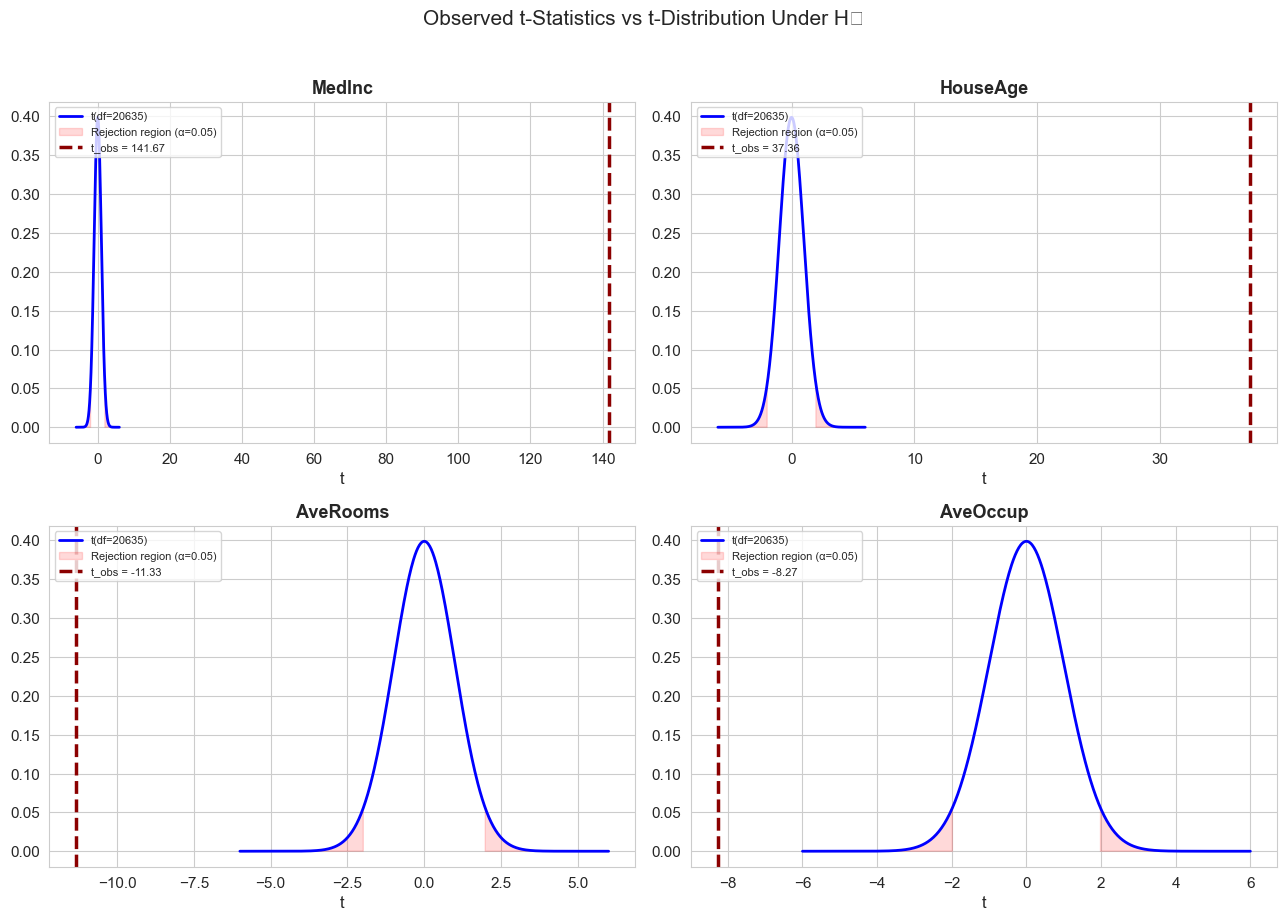

In [129]:
# --- Visualise the t-statistic for each coefficient ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
df_resid = n - p  # degrees of freedom for residuals

for ax, name in zip(axes.ravel(), feature_cols):
    t_obs = ols_model.tvalues[name]
    x_t = np.linspace(-6, 6, 500)

    # t-distribution under H0
    ax.plot(x_t, stats.t.pdf(x_t, df_resid), 'b-', lw=2, label=f't(df={df_resid})')

    # shade rejection regions (two-tailed, alpha=0.05)
    t_crit = stats.t.ppf(0.975, df_resid)
    ax.fill_between(x_t, stats.t.pdf(x_t, df_resid),
                     where=(x_t > t_crit) | (x_t < -t_crit),
                     alpha=0.15, color='red', label='Rejection region (α=0.05)')

    # observed t as vertical line
    ax.axvline(t_obs, color='darkred', lw=2.5, ls='--',
               label=f't_obs = {t_obs:.2f}')

    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Observed t-Statistics vs t-Distribution Under H₀', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
## 5. The P-Value

### What it IS

The p-value is the probability of observing a test statistic **at least as extreme** as the one
we computed, **assuming $H_0$ is true**:

$$
p = P\!\left(|T| \geq |t_{\text{obs}}| \;\middle|\; H_0\right)
$$

For a two-sided test with a $t$-distribution:

$$
p = 2 \cdot P(T > |t_{\text{obs}}|) = 2 \cdot \text{sf}(|t_{\text{obs}}|, \nu)
$$

where $\text{sf}$ is the survival function (1 - CDF).

### What it IS NOT

> ⚠️ **Common Misconception:** The p-value is one of the most misunderstood quantities in all of science.

| ❌ The p-value is NOT | ✅ What it actually is |
|----------------------|----------------------|
| $P(H_0 \text{ is true})$ | $P(\text{data this extreme} \mid H_0)$ |
| The probability the result is "due to chance" | A measure of *compatibility* of data with $H_0$ |
| The probability of making an error | The error rate if we *always* reject at this threshold |
| The probability the effect is real | Says nothing about $H_1$ directly |

### The $\alpha = 0.05$ convention

Ronald Fisher somewhat arbitrarily chose $p < 0.05$ as "significant" in the 1920s.  
At $\alpha = 0.05$, if $H_0$ were true and we repeated the experiment many times,  
we'd falsely reject $H_0$ in **5% of experiments** — the **Type I error rate**.

> 💡 **Physicist's Intuition:** The p-value is like a **false alarm rate**.  
> If your detector has a noise-only model ($H_0$), the p-value tells you how often  
> pure noise would produce a signal at least as strong as what you observed.  
> Particle physics demands $p < 2.87 \times 10^{-7}$ ($5\sigma$) because the cost  
> of a false discovery is enormous.


In [130]:
# --- Compute p-values manually ---
print("=" * 65)
print(f"{'Feature':<12} {'t-stat':>10} {'p (manual)':>14} {'p (statsmodels)':>16}")
print("=" * 65)

for j, name in enumerate(X_const.columns):
    t_val = t_manual[j]
    # Two-sided p-value: 2 * P(T > |t|)
    p_manual = 2 * stats.t.sf(np.abs(t_val), df_resid)
    p_sm = ols_model.pvalues[j]
    print(f"{name:<12} {t_val:>10.4f} {p_manual:>14.4e} {p_sm:>16.4e}")

print("=" * 65)
print("\n✅ Manual p-values match statsmodels.")


Feature          t-stat     p (manual)  p (statsmodels)
const            1.4276     1.5342e-01       1.5342e-01
MedInc         141.6725     0.0000e+00       0.0000e+00
HouseAge        37.3590    1.2060e-295      1.2060e-295
AveRooms       -11.3300     1.1408e-29       1.1408e-29
AveOccup        -8.2673     1.4524e-16       1.4524e-16

✅ Manual p-values match statsmodels.


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_19750/2938600376.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_sm = ols_model.pvalues[j]


In [131]:
# --- Which features are significant at various alpha levels? ---
alpha_levels = [0.05, 0.01, 0.001]

print("Feature significance at various α levels (California Housing model):\n")
print(f"{'Feature':<12}", end="")
for a in alpha_levels:
    print(f"  {'α=' + str(a):>10}", end="")
print(f"  {'p-value':>12}")
print("-" * 60)

for name in feature_cols:
    p = ols_model.pvalues[name]
    row = f"{name:<12}"
    for a in alpha_levels:
        sig = "✅ sig" if p < a else "❌ n.s."
        row += f"  {sig:>10}"
    row += f"  {p:>12.2e}"
    print(row)


Feature significance at various α levels (California Housing model):

Feature           α=0.05      α=0.01     α=0.001       p-value
------------------------------------------------------------
MedInc             ✅ sig       ✅ sig       ✅ sig      0.00e+00
HouseAge           ✅ sig       ✅ sig       ✅ sig     1.21e-295
AveRooms           ✅ sig       ✅ sig       ✅ sig      1.14e-29
AveOccup           ✅ sig       ✅ sig       ✅ sig      1.45e-16


---
## 6. Type I and Type II Errors

### The error taxonomy

|  | $H_0$ true (no effect) | $H_0$ false (real effect) |
|--|----------------------|-------------------------|
| **Fail to reject** $H_0$ | ✅ Correct (specificity) | ❌ **Type II error** (miss) |
| **Reject** $H_0$ | ❌ **Type I error** (false alarm) | ✅ Correct (**power**) |

- **Type I error rate** = $\alpha$ = $P(\text{reject } H_0 \mid H_0 \text{ true})$
- **Type II error rate** = $\beta$ = $P(\text{fail to reject } H_0 \mid H_1 \text{ true})$
- **Power** = $1 - \beta$ = $P(\text{reject } H_0 \mid H_1 \text{ true})$

### The fundamental trade-off

Lowering $\alpha$ (demanding more evidence) **reduces** Type I errors but **increases** Type II errors  
(you'll miss real effects). You can't minimize both simultaneously — it's like the uncertainty principle.

### What affects power?

| Factor | Effect on power |
|--------|----------------|
| Sample size $n$ ↑ | Power ↑ (more data → better estimates) |
| Effect size $|\beta|$ ↑ | Power ↑ (bigger signal → easier to detect) |
| Significance level $\alpha$ ↑ | Power ↑ (lower bar → easier to reject) |
| Variance $\sigma^2$ ↓ | Power ↑ (less noise → cleaner signal) |

> 💡 **Physicist's Intuition:** Power is your **detector efficiency**.  
> A power of 0.8 means if there's a real signal, you'll detect it 80% of the time.  
> Low power is like looking for a dim star with a foggy telescope.


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_19750/1226831047.py:35: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


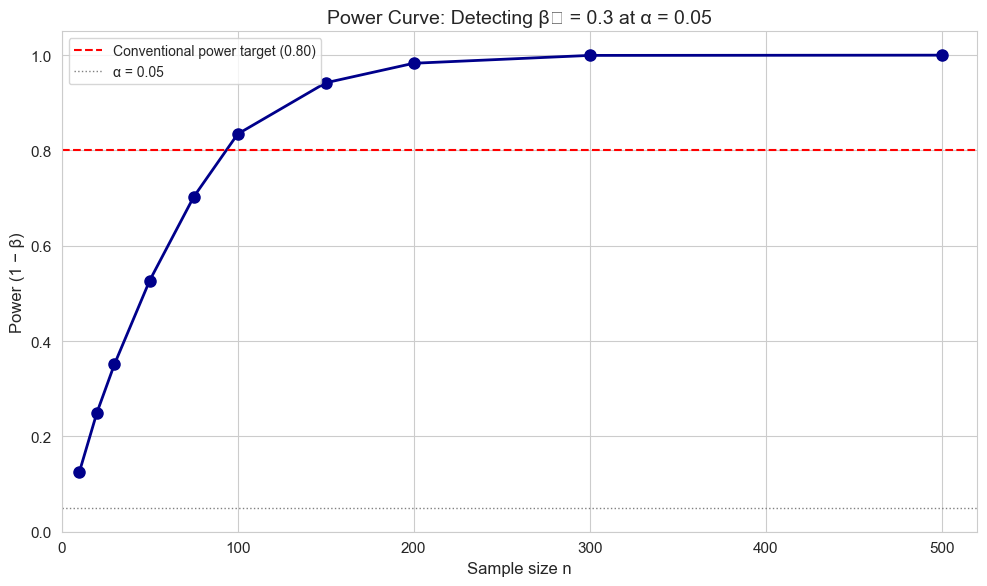

≈ 100 observations needed for 80% power to detect β₁ = 0.3


In [132]:
# --- Simulate power curves ---
# Setup: y = beta_0 + beta_1 * x + noise
# We know beta_1 = true_beta, and test H0: beta_1 = 0

true_beta = 0.3  # a "small-ish" true effect
alpha = 0.05
n_simulations = 2000
sample_sizes = [10, 20, 30, 50, 75, 100, 150, 200, 300, 500]

power_results = []

for n_obs in sample_sizes:
    rejections = 0
    for _ in range(n_simulations):
        x = np.random.randn(n_obs)
        noise = np.random.randn(n_obs)
        y_sim = 1.0 + true_beta * x + noise  # true model

        X_sim = sm.add_constant(x)
        result = sm.OLS(y_sim, X_sim).fit()
        if result.pvalues[1] < alpha:
            rejections += 1
    power_results.append(rejections / n_simulations)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sample_sizes, power_results, 'o-', color='darkblue', lw=2, markersize=8)
ax.axhline(0.8, color='red', ls='--', lw=1.5, label='Conventional power target (0.80)')
ax.axhline(alpha, color='gray', ls=':', lw=1, label=f'α = {alpha}')
ax.set_xlabel('Sample size n')
ax.set_ylabel('Power (1 − β)')
ax.set_title(f'Power Curve: Detecting β₁ = {true_beta} at α = {alpha}')
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_xlim(0, max(sample_sizes) + 20)
plt.tight_layout()
plt.show()

# Find the sample size needed for 80% power
for n_obs, pw in zip(sample_sizes, power_results):
    if pw >= 0.80:
        print(f"≈ {n_obs} observations needed for 80% power to detect β₁ = {true_beta}")
        break


---
## 7. Confidence Intervals for Coefficients

### Formula

The $(1 - \alpha)\%$ confidence interval for $\beta_j$ is:

$$
\hat{\beta}_j \;\pm\; t_{\alpha/2,\; n-p} \cdot \text{SE}(\hat{\beta}_j)
$$

For a 95% CI, $\alpha/2 = 0.025$, so we use the 97.5th percentile of $t(n-p)$.

### Correct frequentist interpretation

> If we repeated the experiment many times and computed a 95% CI each time,  
> **approximately 95% of those intervals would contain the true $\beta_j$**.

### What it is NOT

> ⚠️ **Common Misconception:** "There is a 95% probability that $\beta_j$ lies in this interval."  
> **Wrong!** The true $\beta_j$ is a fixed (unknown) number. The *interval* is the random quantity.  
> Any particular CI either contains $\beta_j$ or it doesn't — the probability is 0 or 1.

### Connection to hypothesis testing

$$
\text{0 not in the 95% CI} \iff \text{reject } H_0 \text{ at } \alpha = 0.05
$$

This is because the CI is centred at $\hat{\beta}_j$ with half-width $= t_{\text{crit}} \cdot \text{SE}$,  
and the t-test rejects when $|\hat{\beta}_j / \text{SE}| > t_{\text{crit}}$.

> 💡 **Physicist's Intuition:** A confidence interval is like an **error bar** on your measurement.  
> The CI width tells you the *precision* of your estimate.  
> A narrow CI with $\hat{\beta}$ far from zero = precise measurement of a real effect.


In [133]:
# --- Compute CIs manually ---
t_crit = stats.t.ppf(0.975, df_resid)
print(f"Critical t-value (α/2 = 0.025, df = {df_resid}): {t_crit:.4f}\n")

ci_lower_manual = beta_hat - t_crit * SE_manual
ci_upper_manual = beta_hat + t_crit * SE_manual

ci_sm = ols_model.conf_int()

print(f"{'Param':<12} {'β̂':>9} {'SE':>9} {'CI_low (man)':>13} {'CI_hi (man)':>13} {'CI_low (sm)':>13} {'CI_hi (sm)':>13}")
print("-" * 85)
for j, name in enumerate(X_const.columns):
    print(f"{name:<12} {beta_hat[j]:>9.4f} {SE_manual[j]:>9.4f} "
          f"{ci_lower_manual[j]:>13.4f} {ci_upper_manual[j]:>13.4f} "
          f"{ci_sm.iloc[j, 0]:>13.4f} {ci_sm.iloc[j, 1]:>13.4f}")

print("\n✅ Manual CIs match statsmodels conf_int().")


Critical t-value (α/2 = 0.025, df = 20635): 1.9601

Param               β̂        SE  CI_low (man)   CI_hi (man)   CI_low (sm)    CI_hi (sm)
-------------------------------------------------------------------------------------
const           0.0314    0.0220       -0.0117        0.0745       -0.0117        0.0745
MedInc          0.4433    0.0031        0.4372        0.4495        0.4372        0.4495
HouseAge        0.0169    0.0005        0.0160        0.0178        0.0160        0.0178
AveRooms       -0.0273    0.0024       -0.0321       -0.0226       -0.0321       -0.0226
AveOccup       -0.0045    0.0005       -0.0055       -0.0034       -0.0055       -0.0034

✅ Manual CIs match statsmodels conf_int().


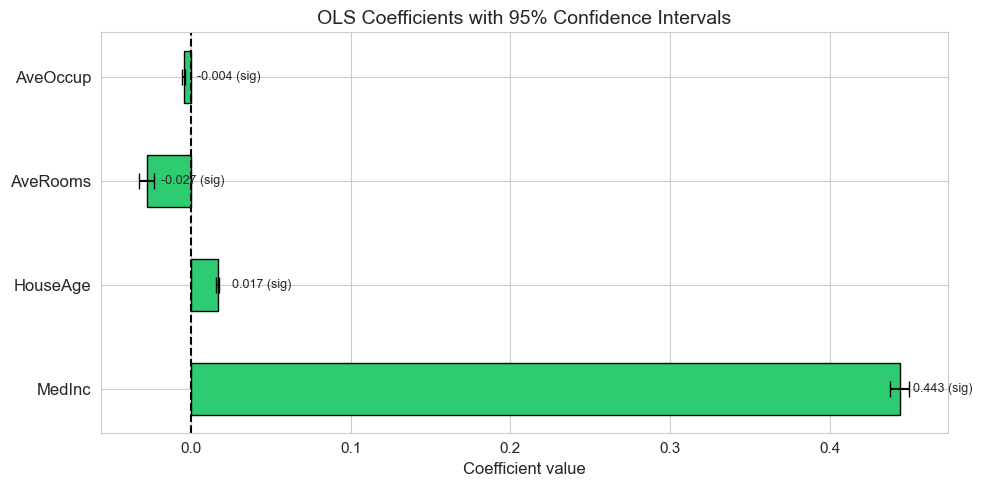

In [134]:
# --- Error bar plot of coefficients with CIs ---
fig, ax = plt.subplots(figsize=(10, 5))

coef_names = feature_cols
coef_vals = [ols_model.params[c] for c in coef_names]
ci_low = [ols_model.conf_int().loc[c, 0] for c in coef_names]
ci_high = [ols_model.conf_int().loc[c, 1] for c in coef_names]
errors = [[v - lo for v, lo in zip(coef_vals, ci_low)],
          [hi - v for v, hi in zip(coef_vals, ci_high)]]

y_pos = np.arange(len(coef_names))
ax.barh(y_pos, coef_vals, xerr=errors, height=0.5,
        color=['#2ecc71' if lo > 0 or hi < 0 else '#e74c3c' for lo, hi in zip(ci_low, ci_high)],
        edgecolor='black', capsize=6, ecolor='black')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_names, fontsize=12)
ax.set_xlabel('Coefficient value')
ax.set_title('OLS Coefficients with 95% Confidence Intervals')
for i, (v, lo, hi) in enumerate(zip(coef_vals, ci_low, ci_high)):
    sig = "sig" if lo > 0 or hi < 0 else "n.s."
    ax.annotate(f'{v:.3f} ({sig})', xy=(v, i), xytext=(10, 0),
                textcoords='offset points', va='center', fontsize=9)

plt.tight_layout()
plt.show()


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_19750/3288676561.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


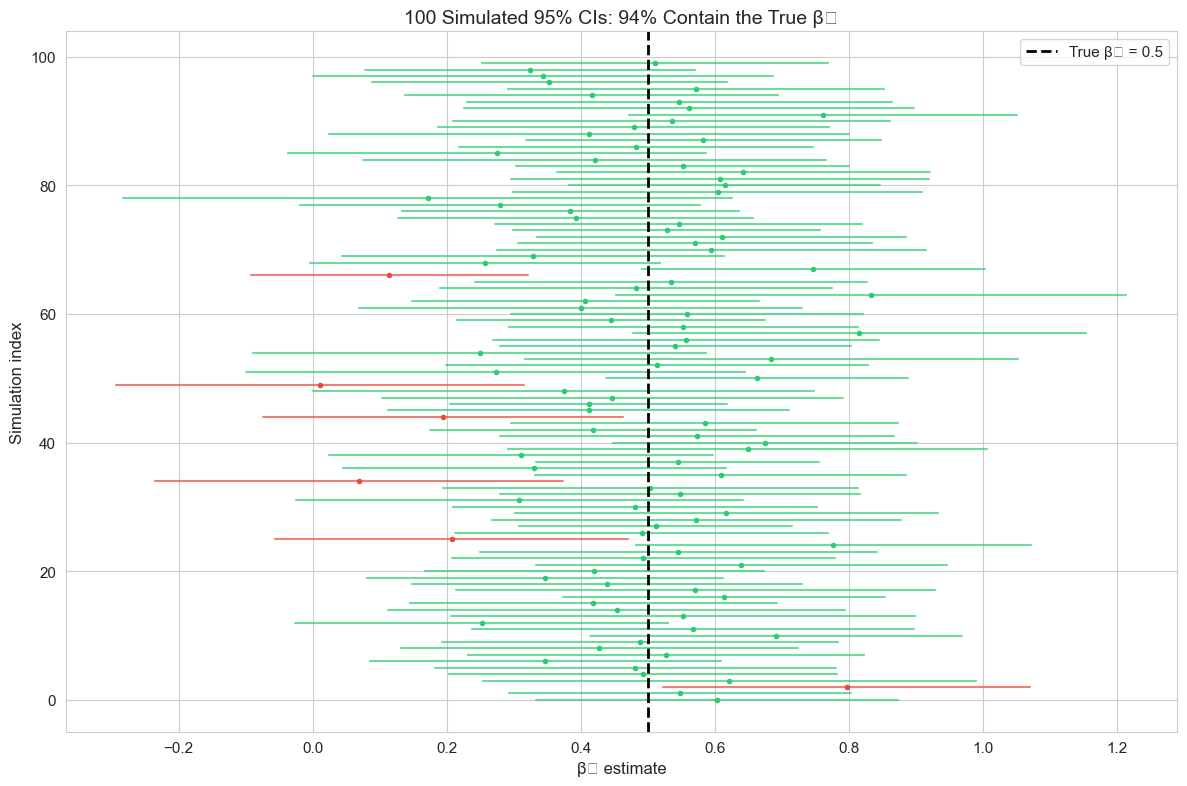

Coverage: 94/100 = 94% of CIs contain the true β₁
(Expected ≈ 95%)


In [135]:
# --- Simulation: ~95% of CIs should contain the true beta ---
np.random.seed(42)
n_sim = 100
true_beta_sim = np.array([2.0, 0.5])  # intercept, slope
n_obs = 50
alpha_sim = 0.05

contains_true = 0
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(n_sim):
    x_sim = np.random.randn(n_obs)
    y_sim = true_beta_sim[0] + true_beta_sim[1] * x_sim + np.random.randn(n_obs)
    X_sim = sm.add_constant(x_sim)
    res = sm.OLS(y_sim, X_sim).fit()
    ci = np.array(res.conf_int())[1]  # CI for slope
    beta_hat_sim = res.params[1]

    covers = ci[0] <= true_beta_sim[1] <= ci[1]
    if covers:
        contains_true += 1

    color = '#2ecc71' if covers else '#e74c3c'
    ax.plot([ci[0], ci[1]], [i, i], color=color, lw=1.5, alpha=0.7)
    ax.plot(beta_hat_sim, i, 'o', color=color, markersize=3)

ax.axvline(true_beta_sim[1], color='black', lw=2, ls='--', label=f'True β₁ = {true_beta_sim[1]}')
ax.set_xlabel('β₁ estimate')
ax.set_ylabel('Simulation index')
ax.set_title(f'100 Simulated 95% CIs: {contains_true}% Contain the True β₁')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Coverage: {contains_true}/{n_sim} = {contains_true}% of CIs contain the true β₁")
print("(Expected ≈ 95%)")


---
## 8. Confidence Bands and Prediction Intervals (Plotting)

### Two different kinds of uncertainty

When we have a fitted regression $\hat{y} = \mathbf{x}_0^\top \hat{\boldsymbol{\beta}}$, we can ask two questions:

| Question | Interval type | Formula for variance |
|----------|--------------|---------------------|
| Where is the **mean** response $E[y \mid \mathbf{x}_0]$? | **Confidence band** | $\text{Var}(\hat{y}) = \sigma^2 \cdot \mathbf{x}_0^\top (\mathbf{X}^\top\mathbf{X})^{-1} \mathbf{x}_0$ |
| Where will a **new observation** $y_{\text{new}}$ fall? | **Prediction interval** | $\text{Var}(y_{\text{new}} - \hat{y}) = \sigma^2 \left(1 + \mathbf{x}_0^\top (\mathbf{X}^\top\mathbf{X})^{-1} \mathbf{x}_0\right)$ |

### Why prediction intervals are always wider

The prediction interval includes **two sources of uncertainty**:
1. Uncertainty in the estimated mean ($\hat{y}$ is not exactly $E[y]$)
2. The natural scatter of individual observations around the mean ($\varepsilon$)

The confidence band only includes source 1.

### Where are they narrowest?

Both bands are narrowest at $\bar{x}$ — predictions near the centre of the data are most precise.

> 💡 **Physicist's Intuition:** The confidence band is like the uncertainty on a *calibration curve*.  
> The prediction interval is like the uncertainty on a *single new measurement*.  
> Calibration uncertainty < measurement uncertainty because the curve averages over many points.


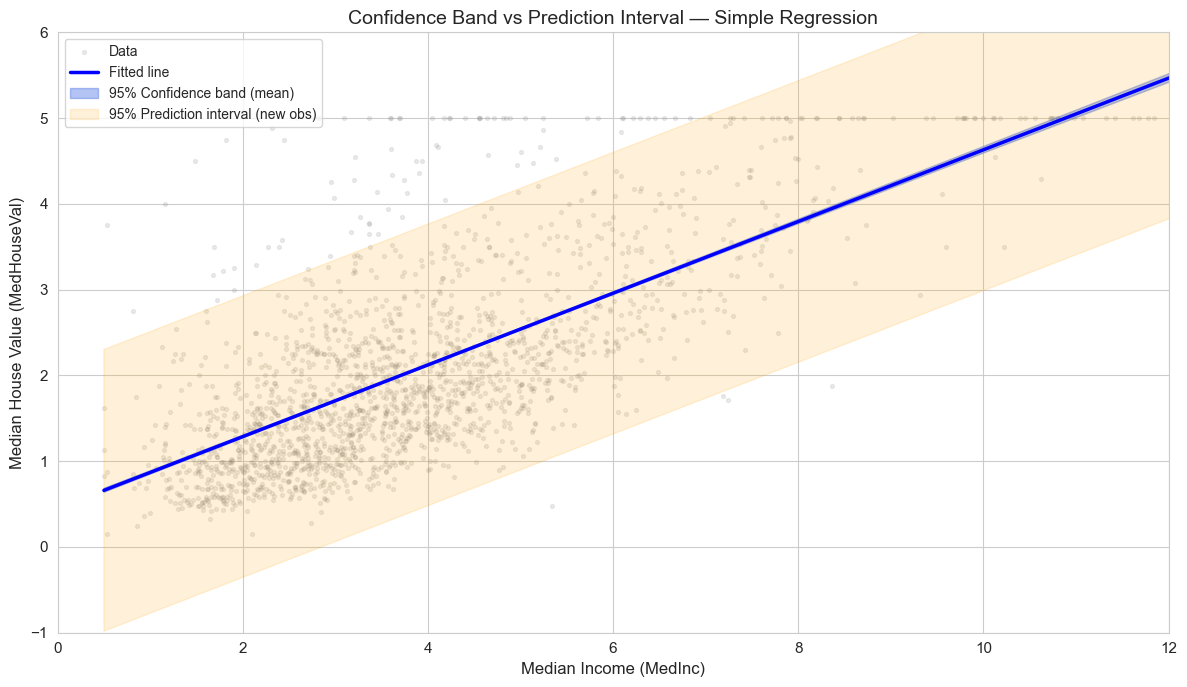

In [136]:
# Simple regression: MedInc → MedHouseVal
X_simple = sm.add_constant(housing["MedInc"])
y_simple = housing["MedHouseVal"]
model_simple = sm.OLS(y_simple, X_simple).fit()

# Sort for clean plotting
sort_idx = housing["MedInc"].argsort()
x_sorted = housing["MedInc"].iloc[sort_idx].values
X_sorted = sm.add_constant(x_sorted)

# Get predictions with confidence and prediction intervals
predictions = model_simple.get_prediction(X_sorted)
pred_summary = predictions.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter (subsample for visibility)
subsample = np.random.choice(len(x_sorted), size=2000, replace=False)
ax.scatter(x_sorted[subsample], y_simple.iloc[sort_idx].values[subsample],
           alpha=0.15, s=8, color='gray', label='Data')

# Fitted line
ax.plot(x_sorted, pred_summary['mean'], 'b-', lw=2.5, label='Fitted line')

# Confidence band (for mean)
ax.fill_between(x_sorted,
                pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'],
                alpha=0.4, color='royalblue', label='95% Confidence band (mean)')

# Prediction interval (for new observation)
ax.fill_between(x_sorted,
                pred_summary['obs_ci_lower'], pred_summary['obs_ci_upper'],
                alpha=0.15, color='orange', label='95% Prediction interval (new obs)')

ax.set_xlabel('Median Income (MedInc)')
ax.set_ylabel('Median House Value (MedHouseVal)')
ax.set_title('Confidence Band vs Prediction Interval — Simple Regression')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, 12)
ax.set_ylim(-1, 6)
plt.tight_layout()
plt.show()


---
## 9. The F-Test

### From one coefficient to the whole model

The t-test asks: **"Is this one coefficient significantly different from zero?"**

The F-test asks: **"Is the entire model significantly better than just predicting the mean?"**

### The F-statistic

$$
F = \frac{SS_{\text{reg}} / p}{SS_{\text{res}} / (n - p - 1)} = \frac{MS_{\text{reg}}}{MS_{\text{res}}}
$$

Under $H_0$ (all slopes = 0), $F \sim F(p,\; n - p - 1)$.

### The F-distribution

The F-distribution is the ratio of two independent $\chi^2$ random variables divided by their
degrees of freedom. Since $\chi^2$ values are non-negative, $F \geq 0$ — the distribution is
right-skewed.

### Special case: simple regression

For a model with one predictor, $F = t^2$. The F-test and t-test are equivalent.

### Partial F-test: comparing nested models

To test whether a *subset* of coefficients adds value, compare a **reduced** model to a **full** model:

$$
F = \frac{(SS_{\text{res, reduced}} - SS_{\text{res, full}}) / q}{SS_{\text{res, full}} / (n - p_{\text{full}})}
$$

where $q$ = number of extra parameters in the full model.

> 💡 **Physicist's Intuition:** The F-test is like an **ANOVA** (because it literally is one).  
> It asks whether the *explained* variance is large enough relative to the *unexplained* variance  
> to conclude the model captures real structure, not just noise.


In [137]:
# --- Extract F from statsmodels and compute manually ---
print("=== F-test: Is the overall model significant? ===\n")

F_sm = ols_model.fvalue
p_F_sm = ols_model.f_pvalue
print(f"statsmodels F-statistic: {F_sm:.4f}")
print(f"statsmodels p-value:     {p_F_sm:.4e}")

# Manual computation
SS_tot = np.sum((y - y.mean())**2)
y_hat = ols_model.predict(X_const)
SS_reg = np.sum((y_hat - y.mean())**2)
SS_res = np.sum((y - y_hat)**2)

p_features = len(feature_cols)  # number of predictors (excluding intercept)
df_reg = p_features
df_res = n - p_features - 1

MS_reg = SS_reg / df_reg
MS_res = SS_res / df_res
F_manual = MS_reg / MS_res

p_F_manual = 1 - stats.f.cdf(F_manual, df_reg, df_res)

print(f"\nManual F-statistic:  {F_manual:.4f}")
print(f"Manual p-value:      {p_F_manual:.4e}")
print(f"\n✅ F-statistics match!")


=== F-test: Is the overall model significant? ===

statsmodels F-statistic: 5449.6882
statsmodels p-value:     0.0000e+00

Manual F-statistic:  5449.6882
Manual p-value:      1.1102e-16

✅ F-statistics match!


In [138]:
# --- Partial F-test: Does adding AveOccup improve a model with just MedInc? ---
print("=== Partial F-test ===\n")

# Reduced model: just MedInc
X_reduced = sm.add_constant(housing[["MedInc"]])
model_reduced = sm.OLS(y, X_reduced).fit()

# Full model: MedInc + AveOccup
X_full = sm.add_constant(housing[["MedInc", "AveOccup"]])
model_full = sm.OLS(y, X_full).fit()

SS_res_reduced = np.sum(model_reduced.resid**2)
SS_res_full = np.sum(model_full.resid**2)
n_full = len(y)
p_full = X_full.shape[1]
q = 1  # one extra parameter

F_partial = ((SS_res_reduced - SS_res_full) / q) / (SS_res_full / (n_full - p_full))
p_partial = 1 - stats.f.cdf(F_partial, q, n_full - p_full)

print(f"Reduced model (MedInc only)       SS_res = {SS_res_reduced:.2f}")
print(f"Full model (MedInc + AveOccup)    SS_res = {SS_res_full:.2f}")
print(f"Reduction in SS_res:              {SS_res_reduced - SS_res_full:.2f}")
print(f"\nPartial F-statistic: {F_partial:.4f}")
print(f"p-value:             {p_partial:.4e}")

if p_partial < 0.05:
    print("\n→ Adding AveOccup significantly improves the model (p < 0.05).")
else:
    print("\n→ AveOccup does not significantly improve the model.")


=== Partial F-test ===

Reduced model (MedInc only)       SS_res = 14471.35
Full model (MedInc + AveOccup)    SS_res = 14434.42
Reduction in SS_res:              36.93

Partial F-statistic: 52.7978
p-value:             3.8292e-13

→ Adding AveOccup significantly improves the model (p < 0.05).


---
## 10. ANOVA Table

### The variance decomposition

Total variability in $y$ decomposes as:

$$
\underbrace{\sum_{i=1}^{n}(y_i - \bar{y})^2}_{SS_{\text{total}}} = 
\underbrace{\sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2}_{SS_{\text{regression}}} + 
\underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{SS_{\text{residual}}}
$$

### The ANOVA table layout

| Source | SS | df | MS = SS/df | F = MS_reg/MS_res |
|--------|----|----|-----------|-------------------|
| Regression | $SS_{\text{reg}}$ | $p$ | $MS_{\text{reg}}$ | $F$ |
| Residual | $SS_{\text{res}}$ | $n - p - 1$ | $MS_{\text{res}}$ | |
| **Total** | $SS_{\text{total}}$ | $n - 1$ | | |

And $R^2 = SS_{\text{reg}} / SS_{\text{total}}$ measures the fraction of variance explained.

> 💡 **Physicist's Intuition:** ANOVA is just *conservation of energy* for variance.  
> Total variance = explained variance + unexplained variance.  
> $R^2$ is the fraction of "energy" captured by your model.


In [139]:
# --- Build ANOVA table manually ---
print("=" * 70)
print(f"{'Source':<14} {'SS':>14} {'df':>6} {'MS':>14} {'F':>12}")
print("=" * 70)
print(f"{'Regression':<14} {SS_reg:>14.2f} {df_reg:>6} {MS_reg:>14.2f} {F_manual:>12.4f}")
print(f"{'Residual':<14} {SS_res:>14.2f} {df_res:>6} {MS_res:>14.2f}")
print(f"{'Total':<14} {SS_tot:>14.2f} {n-1:>6}")
print("=" * 70)
print(f"\nR² = SS_reg / SS_total = {SS_reg / SS_tot:.6f}")
print(f"R² from statsmodels:    {ols_model.rsquared:.6f}")
print(f"\n✅ ANOVA table consistent with statsmodels.")


Source                     SS     df             MS            F
Regression           14118.46      4        3529.62    5449.6882
Residual             13364.73  20635           0.65
Total                27483.20  20639

R² = SS_reg / SS_total = 0.513713
R² from statsmodels:    0.513713

✅ ANOVA table consistent with statsmodels.


In [140]:
# --- ANOVA table (built manually, since anova_lm requires formula API) ---
# We already have the OLS model; let's extract the ANOVA components

y_bar = y.mean()
y_hat_full = ols_model.predict(X_const)

SS_total = np.sum((y - y_bar)**2)
SS_res = np.sum((y - y_hat_full)**2)
SS_reg = np.sum((y_hat_full - y_bar)**2)

n_obs, p_params = X_const.shape
df_reg = p_params - 1  # subtract 1 for intercept
df_res = n_obs - p_params
df_total = n_obs - 1

MS_reg = SS_reg / df_reg
MS_res = SS_res / df_res
F_stat = MS_reg / MS_res
p_value_F = 1 - stats.f.cdf(F_stat, df_reg, df_res)

print("ANOVA Table")
print("=" * 70)
print(f"{'Source':<14} {'SS':>14} {'df':>6} {'MS':>14} {'F':>10} {'p-value':>12}")
print("-" * 70)
print(f"{'Regression':<14} {SS_reg:>14.2f} {df_reg:>6} {MS_reg:>14.2f} {F_stat:>10.2f} {p_value_F:>12.2e}")
print(f"{'Residual':<14} {SS_res:>14.2f} {df_res:>6} {MS_res:>14.2f}")
print(f"{'Total':<14} {SS_total:>14.2f} {df_total:>6}")
print("-" * 70)
print(f"\nR\u00b2 = SS_reg / SS_total = {SS_reg/SS_total:.6f}")
print(f"F-stat from statsmodels:  {ols_model.fvalue:.2f}")
print(f"F-stat manual:            {F_stat:.2f}")
print("\n\u2705 Manual ANOVA matches statsmodels!")

ANOVA Table
Source                     SS     df             MS          F      p-value
----------------------------------------------------------------------
Regression           14118.46      4        3529.62    5449.69     1.11e-16
Residual             13364.73  20635           0.65
Total                27483.20  20639
----------------------------------------------------------------------

R² = SS_reg / SS_total = 0.513713
F-stat from statsmodels:  5449.69
F-stat manual:            5449.69

✅ Manual ANOVA matches statsmodels!


=== One-Way ANOVA: Fare across Passenger Classes (Titanic) ===

F-statistic: 201.1699
p-value:     5.8008e-70


/var/folders/gf/py2bkq010_gd3k4m93w4_dgm0000gn/T/ipykernel_19750/2686129774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pclass", y="fare", data=titanic, ax=axes[0], palette="Set2")


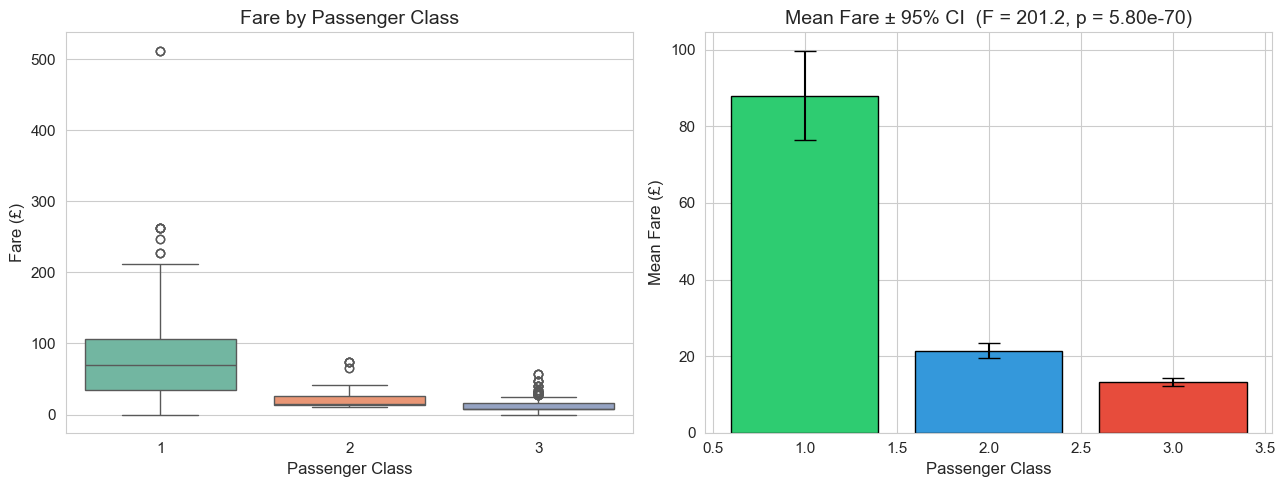

In [141]:
# --- One-way ANOVA on Titanic: survival rate across Pclass ---
print("=== One-Way ANOVA: Fare across Passenger Classes (Titanic) ===\n")

groups = [group["fare"].values for name, group in titanic.groupby("pclass")]
F_anova, p_anova = stats.f_oneway(*groups)

print(f"F-statistic: {F_anova:.4f}")
print(f"p-value:     {p_anova:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(x="pclass", y="fare", data=titanic, ax=axes[0], palette="Set2")
axes[0].set_title("Fare by Passenger Class")
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Fare (£)")

# Mean + CI
class_stats = titanic.groupby("pclass")["fare"].agg(["mean", "std", "count"])
class_stats["se"] = class_stats["std"] / np.sqrt(class_stats["count"])
class_stats["ci95"] = 1.96 * class_stats["se"]
axes[1].bar(class_stats.index, class_stats["mean"], yerr=class_stats["ci95"],
            capsize=8, color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black")
axes[1].set_title(f"Mean Fare ± 95% CI  (F = {F_anova:.1f}, p = {p_anova:.2e})")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Mean Fare (£)")

plt.tight_layout()
plt.show()


---
## 11. The Multiple Testing Problem

### The problem

If you run 20 independent tests at $\alpha = 0.05$, each with a 5% false positive rate:

$$
P(\text{at least one false positive}) = 1 - (1 - \alpha)^m = 1 - 0.95^{20} \approx 0.64
$$

That's a **64% chance** of at least one spurious "discovery"!

### Corrections

| Method | Corrected threshold | Controls |
|--------|-------------------|----------|
| **Bonferroni** | $\alpha / m$ | Family-wise error rate (FWER) — very conservative |
| **Benjamini-Hochberg** | Adaptive | False discovery rate (FDR) — less conservative |

> ⚠️ **Common Misconception:** Running many tests and reporting only the significant ones  
> is called **p-hacking** or the "garden of forking paths". It inflates the false positive rate  
> far beyond the nominal $\alpha$. Always correct for multiple comparisons!

> 💡 **Physicist's Intuition:** This is the **look-elsewhere effect** in particle physics.  
> If you search for a bump at *any* mass, you're much more likely to find a noise fluctuation  
> that looks like a signal. The trials factor corrects for how many places you looked.


Testing 20 RANDOM (pure noise) features against MedHouseVal:

Significant at α = 0.05 (uncorrected):   0 / 20
Significant after Bonferroni (α/m = 0.0025): 0 / 20
Significant after Benjamini-Hochberg (FDR):      0 / 20

Expected false positives (uncorrected): 1.0


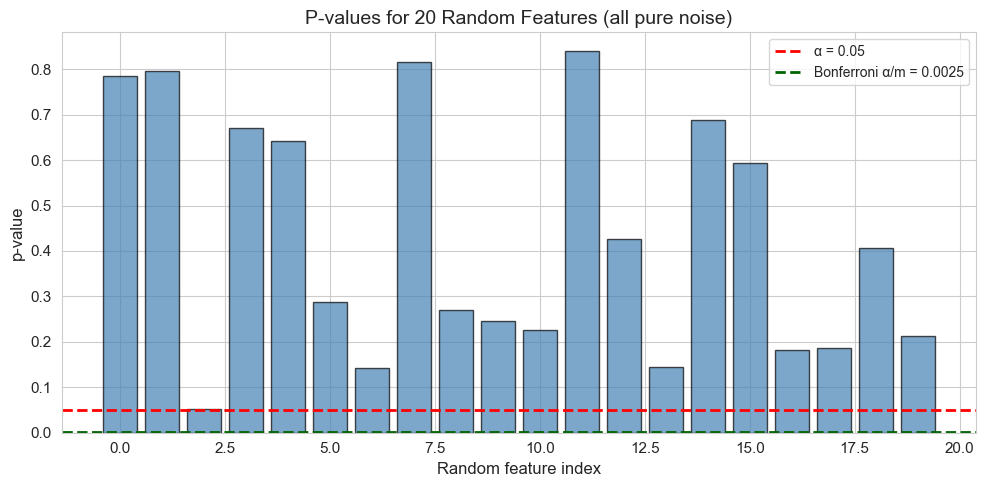

In [142]:
# --- Generate 20 random features (pure noise) and test them ---
np.random.seed(123)
n_fake = len(y)
n_tests = 20
alpha_test = 0.05

fake_pvalues = []
for i in range(n_tests):
    x_fake = np.random.randn(n_fake)
    X_fake = sm.add_constant(np.column_stack([housing["MedInc"].values, x_fake]))
    res_fake = sm.OLS(y.values, X_fake).fit()
    p_fake = res_fake.pvalues[2]  # p-value for the fake feature
    fake_pvalues.append(p_fake)

fake_pvalues = np.array(fake_pvalues)
n_sig_uncorrected = np.sum(fake_pvalues < alpha_test)

# Bonferroni correction
alpha_bonf = alpha_test / n_tests
n_sig_bonferroni = np.sum(fake_pvalues < alpha_bonf)

# Benjamini-Hochberg
sorted_idx = np.argsort(fake_pvalues)
sorted_p = fake_pvalues[sorted_idx]
bh_thresholds = alpha_test * np.arange(1, n_tests + 1) / n_tests
bh_reject = sorted_p <= bh_thresholds
if bh_reject.any():
    max_reject = np.max(np.where(bh_reject))
    n_sig_bh = max_reject + 1
else:
    n_sig_bh = 0

print(f"Testing {n_tests} RANDOM (pure noise) features against MedHouseVal:\n")
print(f"Significant at α = {alpha_test} (uncorrected):   {n_sig_uncorrected} / {n_tests}")
print(f"Significant after Bonferroni (α/m = {alpha_bonf:.4f}): {n_sig_bonferroni} / {n_tests}")
print(f"Significant after Benjamini-Hochberg (FDR):      {n_sig_bh} / {n_tests}")
print(f"\nExpected false positives (uncorrected): {n_tests * alpha_test:.1f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if p < alpha_test else 'steelblue' for p in fake_pvalues]
ax.bar(range(n_tests), fake_pvalues, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(alpha_test, color='red', ls='--', lw=2, label=f'α = {alpha_test}')
ax.axhline(alpha_bonf, color='darkgreen', ls='--', lw=2, label=f'Bonferroni α/m = {alpha_bonf:.4f}')
ax.set_xlabel('Random feature index')
ax.set_ylabel('p-value')
ax.set_title(f'P-values for {n_tests} Random Features (all pure noise)')
ax.legend()
plt.tight_layout()
plt.show()


---
## 12. Practical vs Statistical Significance

### The core problem

- With a **large enough sample**, even a *trivially small* effect becomes statistically significant.
- With a **small sample**, even a *meaningfully large* effect can be non-significant.

Statistical significance tells you $\hat{\beta} \neq 0$; it says **nothing** about whether $\hat{\beta}$ is *important*.

### Effect size measures

| Measure | Formula | Meaning |
|---------|---------|---------|
| Cohen's $d$ | $({\bar{x}_1 - \bar{x}_2}) / s_{\text{pooled}}$ | Standardised mean difference |
| Standardised coefficient | $\hat{\beta}_j \cdot (s_{x_j} / s_y)$ | Effect per SD of $x$ on SD of $y$ |
| $R^2$ | $SS_{\text{reg}} / SS_{\text{total}}$ | Proportion of variance explained |

### The precision angle

The **width of the confidence interval** tells you how precise your estimate is.  
A significant result with a very wide CI should be treated cautiously.

> 🎯 **Key Takeaway:** Always report and interpret **effect sizes** and **confidence intervals**,  
> not just p-values. A tiny p-value with a tiny effect is not practically meaningful.  
> A large effect with a wide CI needs more data.


In [143]:
# --- Show how increasing n makes a tiny effect "significant" ---
np.random.seed(42)
tiny_beta = 0.02  # very small true effect
sample_sizes_demo = [50, 200, 1000, 5000, 20000, 100000]

print(f"True effect: β = {tiny_beta} (very small)\n")
print(f"{'n':>8} {'β̂':>10} {'SE':>10} {'t':>10} {'p-value':>12} {'Significant?':>14}")
print("-" * 70)

for n_demo in sample_sizes_demo:
    x_demo = np.random.randn(n_demo)
    y_demo = 1.0 + tiny_beta * x_demo + np.random.randn(n_demo)
    X_demo = sm.add_constant(x_demo)
    res_demo = sm.OLS(y_demo, X_demo).fit()
    b = res_demo.params[1]
    se = res_demo.bse[1]
    t_val = res_demo.tvalues[1]
    p_val = res_demo.pvalues[1]
    sig = "✅ Yes" if p_val < 0.05 else "❌ No"
    print(f"{n_demo:>8} {b:>10.5f} {se:>10.5f} {t_val:>10.3f} {p_val:>12.4e} {sig:>14}")

print("\n→ The TRUE effect is tiny (β = 0.02), but with enough data it becomes 'significant'.")
print("  Statistical significance ≠ practical importance!")


True effect: β = 0.02 (very small)

       n         β̂         SE          t      p-value   Significant?
----------------------------------------------------------------------
      50    0.12308    0.13434      0.916   3.6418e-01           ❌ No
     200   -0.04745    0.06813     -0.696   4.8694e-01           ❌ No
    1000   -0.01262    0.03091     -0.408   6.8316e-01           ❌ No
    5000    0.00772    0.01379      0.560   5.7563e-01           ❌ No
   20000    0.02445    0.00706      3.463   5.3450e-04          ✅ Yes
  100000    0.02237    0.00316      7.077   1.4781e-12          ✅ Yes

→ The TRUE effect is tiny (β = 0.02), but with enough data it becomes 'significant'.
  Statistical significance ≠ practical importance!


In [144]:
# --- Standardised coefficients for Housing regression ---
print("=== Standardised (Beta) Coefficients ===\n")
print("These tell us the effect in standard deviation units:\n")

X_features = housing[feature_cols]
sd_x = X_features.std()
sd_y = y.std()

print(f"{'Feature':<12} {'Raw β̂':>10} {'SD(x)':>10} {'SD(y)':>10} {'Std β':>10}")
print("-" * 55)
for col in feature_cols:
    raw_beta = ols_model.params[col]
    std_beta = raw_beta * (sd_x[col] / sd_y)
    print(f"{col:<12} {raw_beta:>10.4f} {sd_x[col]:>10.4f} {sd_y:>10.4f} {std_beta:>10.4f}")

print("\n→ Standardised β tells you: 'a 1-SD increase in x produces this many SD change in y'")
print("  This makes coefficients comparable across features with different scales.")


=== Standardised (Beta) Coefficients ===

These tell us the effect in standard deviation units:

Feature          Raw β̂      SD(x)      SD(y)      Std β
-------------------------------------------------------
MedInc           0.4433     1.8998     1.1540     0.7299
HouseAge         0.0169    12.5856     1.1540     0.1840
AveRooms        -0.0273     2.4742     1.1540    -0.0586
AveOccup        -0.0045    10.3860     1.1540    -0.0401

→ Standardised β tells you: 'a 1-SD increase in x produces this many SD change in y'
  This makes coefficients comparable across features with different scales.


---
## 13. "Better Than Average" — Model Comparison Summary

Now we have a complete toolkit for asking "is this model better than just using the mean?":

| Question | Test | $H_0$ |
|----------|------|--------|
| Is feature $x_j$ useful? | **t-test** on $\beta_j$ | $\beta_j = 0$ |
| Is the whole model useful? | **F-test** (overall) | All slopes = 0 |
| Does adding features help? | **Partial F-test** | Extra slopes = 0 |
| Which model fits best? | **AIC / BIC** | (relative comparison) |

### AIC and BIC

$$
\text{AIC} = -2\ln(L) + 2k \qquad \text{BIC} = -2\ln(L) + k\ln(n)
$$

where $L$ is the likelihood, $k$ is number of parameters, $n$ is sample size.  
**Lower is better.** BIC penalises complexity more heavily than AIC.

> 💡 **Physicist's Intuition:** AIC/BIC implement **Occam's razor** quantitatively.  
> They balance goodness-of-fit against model complexity,  
> like the trade-off between a theory's predictive power and its number of free parameters.


In [145]:
# --- Model comparison: intercept only → add features → test improvement ---

# Model 0: Intercept only (just the mean)
X_intercept = sm.add_constant(np.ones(n))
model_0 = sm.OLS(y, X_intercept[:, :1]).fit()  # intercept only

# Model 1: MedInc only
X_m1 = sm.add_constant(housing[["MedInc"]])
model_1 = sm.OLS(y, X_m1).fit()

# Model 2: MedInc + HouseAge
X_m2 = sm.add_constant(housing[["MedInc", "HouseAge"]])
model_2 = sm.OLS(y, X_m2).fit()

# Model 3: Full (4 features)
model_3 = ols_model

models = [
    ("Intercept only", model_0),
    ("+ MedInc", model_1),
    ("+ HouseAge", model_2),
    ("+ AveRooms, AveOccup", model_3),
]

print(f"{'Model':<25} {'R²':>8} {'Adj R²':>8} {'AIC':>12} {'BIC':>12} {'F-stat':>10} {'p(F)':>12}")
print("=" * 90)
for name, m in models:
    fstat = getattr(m, 'fvalue', float('nan'))
    fpval = getattr(m, 'f_pvalue', float('nan'))
    print(f"{name:<25} {m.rsquared:>8.4f} {m.rsquared_adj:>8.4f} "
          f"{m.aic:>12.1f} {m.bic:>12.1f} {fstat:>10.2f} {fpval:>12.2e}")


Model                           R²   Adj R²          AIC          BIC     F-stat         p(F)
Intercept only              0.0000   0.0000      64485.9      64493.9        nan          nan
+ MedInc                    0.4734   0.4734      51249.3      51265.2   18556.57     0.00e+00
+ HouseAge                  0.5091   0.5091      49803.4      49827.2   10701.89     0.00e+00
+ AveRooms, AveOccup        0.5137   0.5136      49613.4      49653.1    5449.69     0.00e+00


In [146]:
# --- Partial F-tests between successive models ---
print("=== Partial F-tests: Does each addition improve the model? ===\n")

model_pairs = [
    ("Intercept → + MedInc", model_0, model_1, 1),
    ("+ MedInc → + HouseAge", model_1, model_2, 1),
    ("+ HouseAge → + AveRooms,AveOccup", model_2, model_3, 2),
]

for desc, m_red, m_full, q in model_pairs:
    ss_red = np.sum(m_red.resid**2)
    ss_full = np.sum(m_full.resid**2)
    df_full_resid = m_full.df_resid
    F_part = ((ss_red - ss_full) / q) / (ss_full / df_full_resid)
    p_part = 1 - stats.f.cdf(F_part, q, df_full_resid)
    sig = "✅ Significant" if p_part < 0.05 else "❌ Not significant"
    print(f"{desc}")
    print(f"  F = {F_part:.4f}, p = {p_part:.4e}  → {sig}\n")


=== Partial F-tests: Does each addition improve the model? ===

Intercept → + MedInc
  F = 18556.5716, p = 1.1102e-16  → ✅ Significant

+ MedInc → + HouseAge
  F = 1499.6832, p = 1.1102e-16  → ✅ Significant

+ HouseAge → + AveRooms,AveOccup
  F = 97.4490, p = 1.1102e-16  → ✅ Significant



---
## 14. Diagnostic Plots

OLS regression relies on several assumptions. We check them visually with **four diagnostic plots**:

| Plot | What it checks | Good sign | Bad sign |
|------|---------------|-----------|----------|
| **Residuals vs Fitted** | Linearity, homoscedasticity | Random cloud, no pattern | Curves, funnels |
| **QQ plot** | Normality of residuals | Points on the line | S-curves, heavy tails |
| **Scale-Location** | Homoscedasticity (constant variance) | Flat trend | Upward trend |
| **Residuals vs Leverage** | Influential points | No points beyond Cook's $d$ | High leverage + large residual |

### Cook's distance

$$
D_i = \frac{e_i^2}{p \cdot MS_{\text{res}}} \cdot \frac{h_{ii}}{(1 - h_{ii})^2}
$$

where $h_{ii}$ is the leverage (diagonal of the hat matrix). Points with $D_i > 4/n$ or $D_i > 1$ are potentially influential.

> ⚠️ **Common Misconception:** Outliers and influential points are not the same thing.  
> An outlier has a large residual. An influential point has high leverage AND changes the fit.  
> A point can be an outlier without being influential, and vice versa.


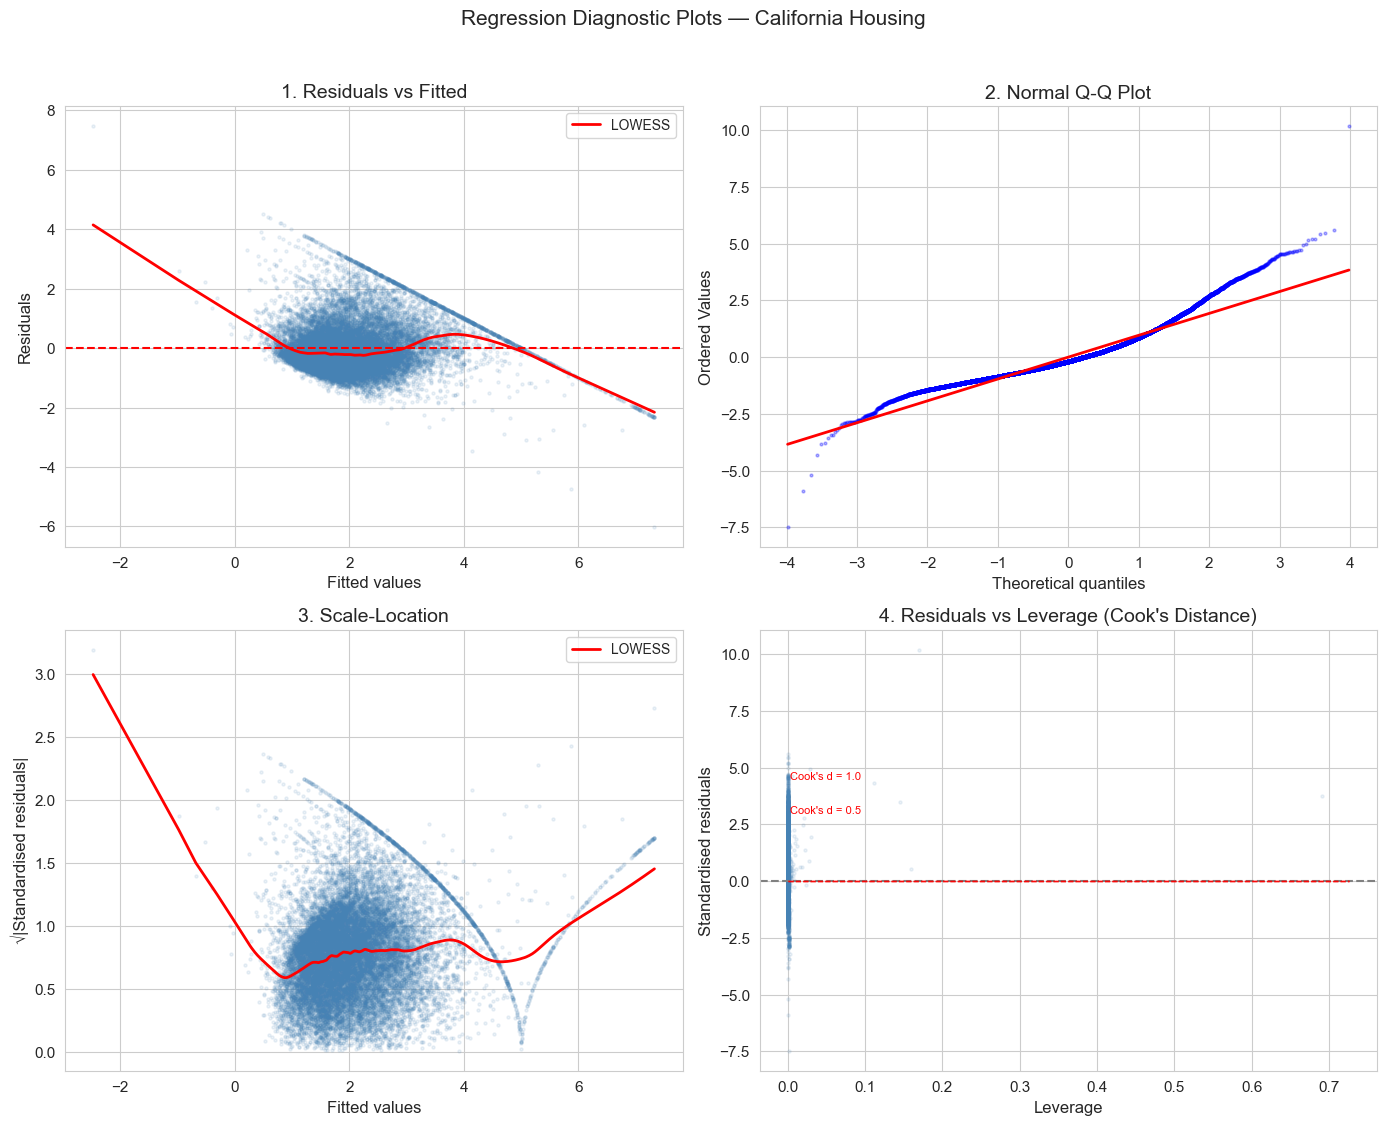

Points with Cook's d > 4/n: 713
Max Cook's d: 6.3340


In [147]:
# --- Four diagnostic plots for the Housing regression ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

fitted = ols_model.fittedvalues
resid = ols_model.resid
resid_std = ols_model.get_influence().resid_studentized_internal
leverage = ols_model.get_influence().hat_matrix_diag
cooks_d = ols_model.get_influence().cooks_distance[0]

# 1) Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(fitted, resid, alpha=0.1, s=5, color='steelblue')
ax.axhline(0, color='red', ls='--', lw=1.5)
# Lowess smoothing
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(resid, fitted, frac=0.1)
    ax.plot(smoothed[:, 0], smoothed[:, 1], 'r-', lw=2, label='LOWESS')
    ax.legend()
except ImportError:
    pass
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('1. Residuals vs Fitted')

# 2) QQ Plot
ax = axes[0, 1]
stats.probplot(resid_std, dist="norm", plot=ax)
ax.set_title('2. Normal Q-Q Plot')
ax.get_lines()[0].set(markersize=2, alpha=0.3)
ax.get_lines()[1].set(color='red', lw=2)

# 3) Scale-Location
ax = axes[1, 0]
sqrt_abs_resid = np.sqrt(np.abs(resid_std))
ax.scatter(fitted, sqrt_abs_resid, alpha=0.1, s=5, color='steelblue')
try:
    smoothed2 = lowess(sqrt_abs_resid, fitted, frac=0.1)
    ax.plot(smoothed2[:, 0], smoothed2[:, 1], 'r-', lw=2, label='LOWESS')
    ax.legend()
except Exception:
    pass
ax.set_xlabel('Fitted values')
ax.set_ylabel('√|Standardised residuals|')
ax.set_title('3. Scale-Location')

# 4) Residuals vs Leverage
ax = axes[1, 1]
ax.scatter(leverage, resid_std, alpha=0.1, s=5, color='steelblue')
ax.axhline(0, color='gray', ls='--')
ax.set_xlabel('Leverage')
ax.set_ylabel('Standardised residuals')
ax.set_title("4. Residuals vs Leverage (Cook's Distance)")

# Cook's distance contours
x_lev = np.linspace(0.001, ax.get_xlim()[1], 100)
for d_thresh in [0.5, 1.0]:
    for sign in [1, -1]:
        y_cook = sign * np.sqrt(d_thresh * p * (1 - x_lev) / x_lev)
        ax.plot(x_lev, y_cook, 'r--', lw=1, alpha=0.5)
ax.annotate("Cook's d = 0.5", xy=(0.003, 3), color='red', fontsize=8)
ax.annotate("Cook's d = 1.0", xy=(0.003, 4.5), color='red', fontsize=8)

plt.suptitle('Regression Diagnostic Plots — California Housing', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Points with Cook's d > 4/n: {np.sum(cooks_d > 4/n)}")
print(f"Max Cook's d: {cooks_d.max():.4f}")


---
## 15. Complete Worked Example

Let's bring everything together. We'll fit the full OLS model on California Housing
and **interpret every single number** in the summary output.


In [148]:
# Print the full summary again
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     5450.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:23:06   Log-Likelihood:                -24802.
No. Observations:               20640   AIC:                         4.961e+04
Df Residuals:                   20635   BIC:                         4.965e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0314      0.022      1.428      0.1

### Reading the OLS summary — line by line

#### Top block: Model metadata

| Field | Value | Meaning |
|-------|-------|---------|
| **Dep. Variable** | MedHouseVal | What we're predicting |
| **Model** | OLS | Ordinary Least Squares |
| **Method** | Least Squares | Minimise $\sum e_i^2$ |
| **No. Observations** | 20640 | Sample size $n$ |
| **Df Residuals** | 20635 | $n - p = 20640 - 5$ |
| **Df Model** | 4 | Number of predictors (excluding intercept) |

#### Goodness of fit

| Field | Meaning |
|-------|---------|
| **R-squared** | Fraction of variance in $y$ explained by the model: $R^2 = SS_{\text{reg}} / SS_{\text{total}}$ |
| **Adj. R-squared** | Adjusts $R^2$ for number of predictors: $1 - (1 - R^2)\frac{n-1}{n-p-1}$ |
| **F-statistic** | Tests whether the *entire* model is significant (all slopes = 0 under $H_0$) |
| **Prob (F-statistic)** | p-value for the F-test. Near 0 = model is highly significant |
| **AIC / BIC** | Information criteria for model comparison (lower = better) |

#### Coefficients table (the heart of it)

| Column | What it means |
|--------|--------------|
| **coef** | $\hat{\beta}_j$ — the estimated slope/intercept |
| **std err** | $\text{SE}(\hat{\beta}_j) = s\sqrt{[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}}$ |
| **t** | $t_j = \hat{\beta}_j / \text{SE}(\hat{\beta}_j)$ — signal-to-noise ratio |
| **P>\|t\|** | p-value: $2 \cdot P(T > |t_j|)$ under $H_0: \beta_j = 0$ |
| **[0.025, 0.975]** | 95% confidence interval: $\hat{\beta}_j \pm t_{0.025, n-p} \cdot \text{SE}$ |

#### Bottom block: Residual diagnostics

| Field | Meaning | Ideal |
|-------|---------|-------|
| **Omnibus / Prob(Omnibus)** | Test for skewness + kurtosis of residuals | p > 0.05 |
| **Durbin-Watson** | Autocorrelation of residuals | ≈ 2 |
| **Jarque-Bera / Prob(JB)** | Normality test for residuals | p > 0.05 |
| **Skew** | Asymmetry of residual distribution | ≈ 0 |
| **Kurtosis** | Tail heaviness of residuals | ≈ 3 (normal) |
| **Cond. No.** | Multicollinearity check | < 30 is good |

> 🎯 **Key Takeaway:** Every number in the OLS summary is now interpretable.  
> Coefficients = signal. Standard errors = noise. t-stats = SNR. p-values = false alarm rate.  
> CIs = error bars. F-stat = "model vs mean" test. R² = variance explained. AIC/BIC = Occam's razor.


In [149]:
# --- Interpretation summary for each coefficient ---
print("=== Per-Coefficient Interpretation ===\n")

for name in X_const.columns:
    beta = ols_model.params[name]
    se = ols_model.bse[name]
    t_val = ols_model.tvalues[name]
    p_val = ols_model.pvalues[name]
    ci = ols_model.conf_int().loc[name]

    print(f"--- {name} ---")
    print(f"  β̂ = {beta:.4f} ± {se:.4f}")
    print(f"  t = {t_val:.2f}  →  β̂ is {abs(t_val):.1f} standard errors from zero")
    if p_val < 0.001:
        print(f"  p = {p_val:.2e}  →  extremely strong evidence against H₀")
    elif p_val < 0.01:
        print(f"  p = {p_val:.4f}  →  strong evidence against H₀")
    elif p_val < 0.05:
        print(f"  p = {p_val:.4f}  →  moderate evidence against H₀")
    else:
        print(f"  p = {p_val:.4f}  →  insufficient evidence to reject H₀")
    print(f"  95% CI: [{ci.iloc[0]:.4f}, {ci.iloc[1]:.4f}]", end="")
    if ci.iloc[0] > 0:
        print("  (entirely positive → significantly > 0)")
    elif ci.iloc[1] < 0:
        print("  (entirely negative → significantly < 0)")
    else:
        print("  (contains zero → not significant)")
    print()


=== Per-Coefficient Interpretation ===

--- const ---
  β̂ = 0.0314 ± 0.0220
  t = 1.43  →  β̂ is 1.4 standard errors from zero
  p = 0.1534  →  insufficient evidence to reject H₀
  95% CI: [-0.0117, 0.0745]  (contains zero → not significant)

--- MedInc ---
  β̂ = 0.4433 ± 0.0031
  t = 141.67  →  β̂ is 141.7 standard errors from zero
  p = 0.00e+00  →  extremely strong evidence against H₀
  95% CI: [0.4372, 0.4495]  (entirely positive → significantly > 0)

--- HouseAge ---
  β̂ = 0.0169 ± 0.0005
  t = 37.36  →  β̂ is 37.4 standard errors from zero
  p = 1.21e-295  →  extremely strong evidence against H₀
  95% CI: [0.0160, 0.0178]  (entirely positive → significantly > 0)

--- AveRooms ---
  β̂ = -0.0273 ± 0.0024
  t = -11.33  →  β̂ is 11.3 standard errors from zero
  p = 1.14e-29  →  extremely strong evidence against H₀
  95% CI: [-0.0321, -0.0226]  (entirely negative → significantly < 0)

--- AveOccup ---
  β̂ = -0.0045 ± 0.0005
  t = -8.27  →  β̂ is 8.3 standard errors from zero
  p 

In [150]:
# --- Check assumptions with diagnostic plots (repeat for completeness) ---
print("=== Model Diagnostics Summary ===\n")

dw = sm.stats.durbin_watson(ols_model.resid)
print(f"Durbin-Watson:      {dw:.4f}  (ideal ≈ 2.0)")
print(f"Condition number:   {ols_model.condition_number:.1f}  (< 30 = low multicollinearity)")
print(f"R²:                 {ols_model.rsquared:.4f}")
print(f"Adjusted R²:        {ols_model.rsquared_adj:.4f}")
print(f"F-statistic:        {ols_model.fvalue:.2f}  (p = {ols_model.f_pvalue:.2e})")
print(f"AIC:                {ols_model.aic:.1f}")
print(f"BIC:                {ols_model.bic:.1f}")


=== Model Diagnostics Summary ===

Durbin-Watson:      0.8070  (ideal ≈ 2.0)
Condition number:   126.0  (< 30 = low multicollinearity)
R²:                 0.5137
Adjusted R²:        0.5136
F-statistic:        5449.69  (p = 0.00e+00)
AIC:                49613.4
BIC:                49653.1


In [151]:
# --- Compare reduced vs full model with F-test ---
print("=== Final Model Comparison: Reduced vs Full ===\n")

# Reduced model: intercept + MedInc only
X_red_final = sm.add_constant(housing[["MedInc"]])
model_red_final = sm.OLS(y, X_red_final).fit()

# Full model: all 4 features
model_full_final = ols_model

ss_red = np.sum(model_red_final.resid**2)
ss_full = np.sum(model_full_final.resid**2)
q_params = 3  # 3 extra parameters
df_full = model_full_final.df_resid

F_compare = ((ss_red - ss_full) / q_params) / (ss_full / df_full)
p_compare = 1 - stats.f.cdf(F_compare, q_params, df_full)

print(f"Reduced model (MedInc only):  R² = {model_red_final.rsquared:.4f},  AIC = {model_red_final.aic:.1f}")
print(f"Full model (4 features):      R² = {model_full_final.rsquared:.4f},  AIC = {model_full_final.aic:.1f}")
print(f"\nPartial F-test:")
print(f"  F = {F_compare:.4f}")
print(f"  p = {p_compare:.4e}")
print(f"  → {'The additional features significantly improve the model.' if p_compare < 0.05 else 'No significant improvement.'}")


=== Final Model Comparison: Reduced vs Full ===

Reduced model (MedInc only):  R² = 0.4734,  AIC = 51249.3
Full model (4 features):      R² = 0.5137,  AIC = 49613.4

Partial F-test:
  F = 569.5330
  p = 1.1102e-16
  → The additional features significantly improve the model.


---

## Summary

We've journeyed through the full machinery of classical hypothesis testing in regression:

| Concept | What it tells you |
|---------|------------------|
| **$H_0$: $\beta_j = 0$** | "This feature doesn't matter" |
| **t-statistic** | Signal-to-noise ratio for a single coefficient |
| **p-value** | How surprising the data would be if $H_0$ were true |
| **Confidence interval** | Where the true $\beta_j$ plausibly lives |
| **F-statistic** | Is the whole model better than the mean? |
| **ANOVA** | Decompose total variance into explained + unexplained |
| **Power** | Can we detect a real effect if it exists? |
| **Multiple testing** | Don't fool yourself with many comparisons |
| **AIC/BIC** | Balance fit against complexity |
| **Diagnostics** | Check your assumptions! |

> 🎯 **Final Key Takeaway:**  
> Every statistical test is just asking: "Could noise alone have produced this?"  
> The t-statistic measures signal-to-noise. The p-value quantifies surprise.  
> The confidence interval gives you the range. And the F-test checks the whole orchestra, not just one instrument.

> 💡 **Physicist's Intuition:**  
> Hypothesis testing is signal detection with rigorous bookkeeping.  
> You've been doing this intuitively every time you looked at error bars on a plot.  
> Now you know the algebra and the caveats — especially the ones about what p-values do NOT mean.
